# **SPREAD LOCATOR PROJECT**

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

**Load Dataset**

In [3]:
df = pd.read_csv("transactions.csv")
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


# **Fit Bernoulli & Binomial Distribution**

**Bernoulli (Transaction Success)**

In [14]:
df['success'] = df['transaction_status'].apply(lambda x: 1 if x == "Success" else 0)

p = df['success'].mean()
print("Estimated p (Success Probability):", p)


Estimated p (Success Probability): 0.44545454545454544


**Binomial (Weekly Transaction Count)**

In [5]:
mean_weekly = df['transaction_count'].mean()
n = df['transaction_count'].max()
p_binom = mean_weekly / n

print("Estimated n:", n)
print("Estimated p:", p_binom)

Estimated n: 9
Estimated p: 0.31717171717171716


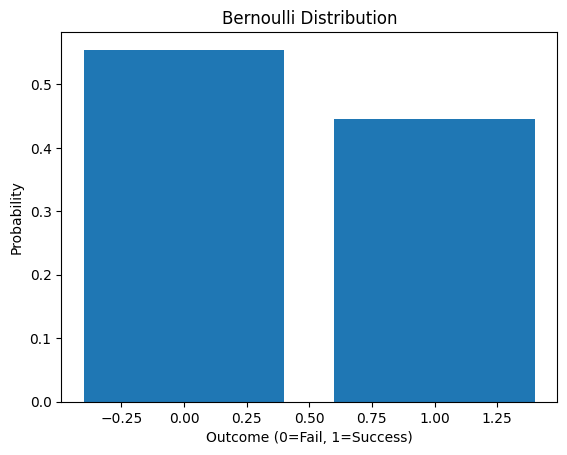

In [17]:
x_vals = [0, 1]
pmf_vals = [1 - p, p]
plt.figure()
plt.bar(x_vals, pmf_vals)
plt.title("Bernoulli Distribution")
plt.xlabel("Outcome (0=Fail, 1=Success)")
plt.ylabel("Probability")
plt.show()

# **Fit Poisson Distribution**

Lambda (Average transactions/day): 7.096774193548387


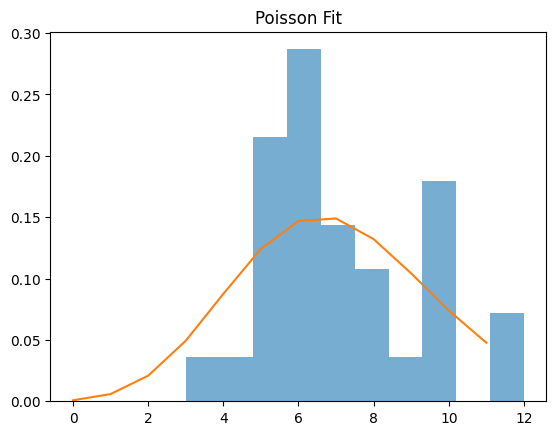

In [6]:
daily_counts = df.groupby('transaction_date').size()
lambda_poisson = daily_counts.mean()

print("Lambda (Average transactions/day):", lambda_poisson)

# Plot comparison
x = np.arange(0, daily_counts.max())
plt.hist(daily_counts, density=True, alpha=0.6)
plt.plot(x, stats.poisson.pmf(x, lambda_poisson))
plt.title("Poisson Fit")
plt.show()

# **Model Transaction Amount (Log-Normal & Power Law)**

**Log-Normal Fit**

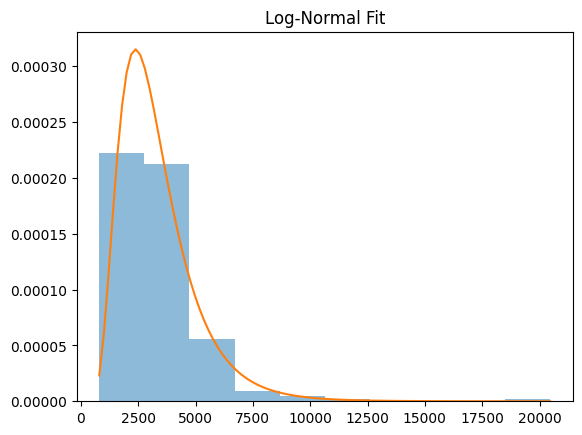

In [7]:
shape, loc, scale = stats.lognorm.fit(df['transaction_amount'], floc=0)

x = np.linspace(df['transaction_amount'].min(),
                df['transaction_amount'].max(), 100)

pdf_lognorm = stats.lognorm.pdf(x, shape, loc, scale)

plt.hist(df['transaction_amount'], density=True, alpha=0.5)
plt.plot(x, pdf_lognorm)
plt.title("Log-Normal Fit")
plt.show()

**Power Law Fit**

In [8]:
alpha = stats.powerlaw.fit(df['transaction_amount'])[0]
print("Estimated alpha:", alpha)

Estimated alpha: 0.41232325172331613


# **Q-Q Plot**

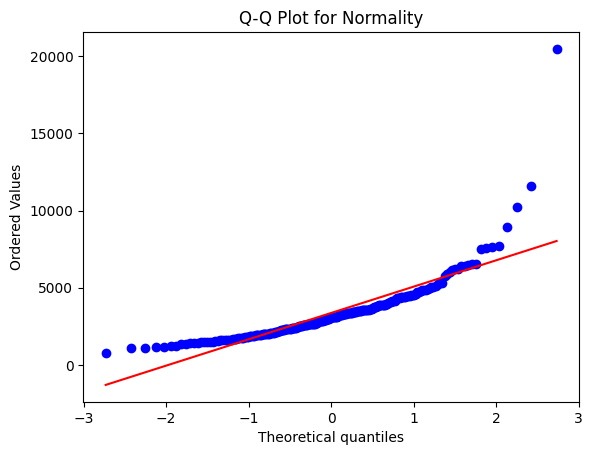

In [9]:
stats.probplot(df['transaction_amount'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Normality")
plt.show()

# **Box-Cox Transform**

Lambda: -0.18083390743966327


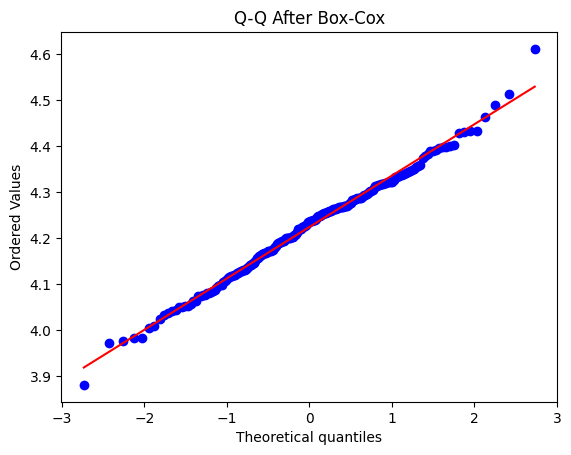

In [10]:
transformed_data, lambda_bc = boxcox(df['transaction_amount'])

print("Lambda:", lambda_bc)

stats.probplot(transformed_data, dist="norm", plot=plt)
plt.title("Q-Q After Box-Cox")
plt.show()

# **Calculate Z-Scores & Probability > ₹5000**

In [11]:
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()

z_5000 = (5000 - mean) / std

prob = 1 - stats.norm.cdf(z_5000)

print("Z-score:", z_5000)
print("Probability > 5000:", prob)

Z-score: 0.8232880785671723
Probability > 5000: 0.20517209567554384


#**PDF and CDF**

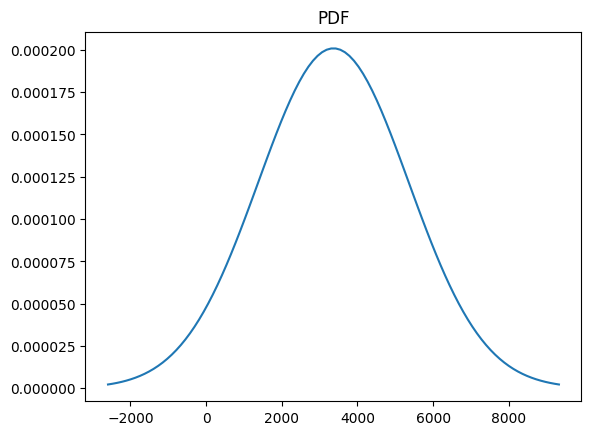

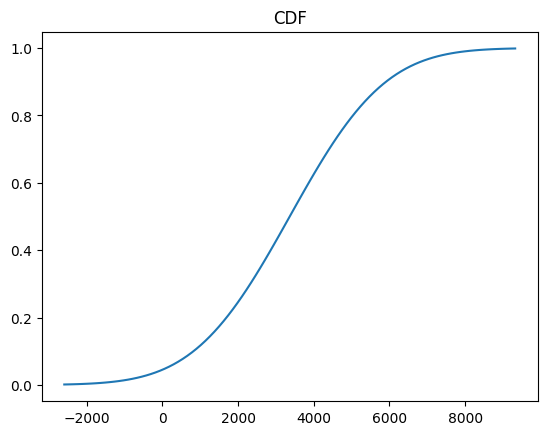

In [12]:
x = np.linspace(mean - 3*std, mean + 3*std, 100)

pdf = stats.norm.pdf(x, mean, std)
cdf = stats.norm.cdf(x, mean, std)

plt.plot(x, pdf)
plt.title("PDF")
plt.show()

plt.plot(x, cdf)
plt.title("CDF")
plt.show()